<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Sewanee_FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

https://lpdaac.usgs.gov/documents/980/gedi_l2b_dictionary_P003_v2.html

# Setup

In [1]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 640.9/640.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 41.2 MB/s eta 0:00:00


In [2]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models
import folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.4 MB/s eta 0:00:00


In [3]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [4]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee


In [6]:

s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")
GEDIindicesB_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021")
HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")
landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')


Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2021, {}, 's1Ascending_2021')
Map.addLayer(DEMindices_2021, {}, 'DEMindices_2021')
Map.addLayer(GEDIindicesA_2021, {}, 'GEDIindicesA_2021')
Map.addLayer(GEDIindicesB_2021, {}, 'GEDIindicesB_2021')
Map.addLayer(HLS_2021, {}, 'HLS_2021')
Map.addLayer(LandsatComposite_2021, {}, 'LandsatComposite_2021')
Map.addLayer(LandsatIndices_2021, {}, 'LandsatIndices_2021')
Map.addLayer(S2Composite_2021, {}, 'S2Composite_2021')
Map.addLayer(S2Indices_2021, {}, 'S2Indices_2021')
Map.addLayer(landsatTasseledCapIndices_2021, {}, 'landsatTasseledCapIndices_2021')



# stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)
stacked = s1Ascending_2021.addBands(DEMindices_2021).addBands(LandsatComposite_2021).addBands(LandsatIndices_2021).addBands(landsatTasseledCapIndices_2021).addBands(HLS_2021).addBands(S2Composite_2021).addBands(S2Indices_2021)


#.addBands(GEDIindicesA_2022)
#.addBands(GEDIindicesB_2022)

Map.addLayer(stacked, {}, 'stacked');


Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

#Spatial Autocorrelation Block

In [7]:
#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2021.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)


proj = GEDIindicesA_2021.projection()
grid = ROI.geometry().coveringGrid(proj, 30)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

Image Chips-> arrays

In [ ]:
# # import ee
# # import geemap
# # import numpy as np
# import matplotlib.pyplot as plt

# # ee.Initialize(project='servir-sco-assets')

# # ─────────────────────────────────────────
# # 1.  Build the stacked image
# # ─────────────────────────────────────────
# stacked = (
#     s1Ascending_2021
#     .addBands(DEMindices_2021)
#     .addBands(LandsatComposite_2021)
#     .addBands(LandsatIndices_2021)
#     .addBands(landsatTasseledCapIndices_2021)
#     .addBands(HLS_2021)
#     .addBands(S2Composite_2021)
#     .addBands(S2Indices_2021)
# )

# # ─────────────────────────────────────────
# # 2.  Create the sampling grid
# # ─────────────────────────────────────────
# proj   = s1Ascending_2021.projection()
# grid   = ROI.geometry().coveringGrid(proj, 10)
# grid   = ee.FeatureCollection(grid).randomColumn("random", 42)

# val_samp  = grid.filter('random <= 0.1')
# test_samp = grid.filter('random <= 0.3 and random > 0.1')
# train_samp= grid.filter('random > 0.3')

# # ─────────────────────────────────────────
# # 3.  Helper to extract 128×128 chips
# # ─────────────────────────────────────────
# def extract_chips(sample_fc, label, image, chip_size=128, scale=10):
#     """
#     Returns a list of NumPy arrays shaped (rows, cols, bands) == (128, 128, nBands)
#     """
#     chips   = []
#     half    = chip_size * scale / 2        # half-width in map units (m)
#     samples = sample_fc.limit(3).getInfo()['features']   # limit(3) for quick test

#     for f in samples:
#         # centre of the cell
#         pt      = ee.Geometry(f['geometry']).centroid()
#         region  = pt.buffer(half, proj=proj).bounds()

#         try:
#             np_arr = geemap.ee_to_numpy(          # NEW: use ee_object arg
#                 ee_object=image,
#                 region=region,
#                 scale=scale          # DO NOT pass 'size'; region+scale controls pixel dims
#             )
#             if np_arr is not None:
#                 chips.append(np_arr)
#                 print(f"{label} chip → shape: {np_arr.shape},  size: {np_arr.size}")
#                 # quick visual check
#                 plt.imshow(np_arr[:, :, 0], cmap='gray')
#                 plt.title(f"{label} chip preview")
#                 plt.axis('off')
#                 plt.show()
#         except Exception as e:
#             print(f"{label}: error on chip → {e}")
#     return chips

# # ─────────────────────────────────────────
# # 4.  Run extraction
# # ─────────────────────────────────────────
# val_chips   = extract_chips(val_samp,   'Validation', stacked)
# test_chips  = extract_chips(test_samp,  'Test',       stacked)
# train_chips = extract_chips(train_samp, 'Train',      stacked)

# print(f"Validation chips: {len(val_chips)}")
# print(f"Test chips:       {len(test_chips)}")
# print(f"Train chips:      {len(train_chips)}")


Validation: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Validation: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Validation: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Test: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Test: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Test: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Train: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero error margin.
Train: error on chip → Geometry.centroid: Unable to perform this geometry operation. Please specify a non-zero er

In [9]:
!pwd

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee


In [8]:
!pip install retry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 3.3 MB/s eta 0:00:00


In [ ]:
# # -------------------------------------------------------------
# # 0. Imports and Earth-Engine initialisation
# # -------------------------------------------------------------
# import ee, geemap, logging, multiprocessing, os, requests, shutil
# from retry import retry      # pip install retry

# # ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")   # high-volume endpoint

# # # -------------------------------------------------------------
# # # 1. Your stacked image
# # # -------------------------------------------------------------
# # stacked = (
# #     s1Ascending_2021
# #       .addBands(DEMindices_2021)
# #       .addBands(LandsatComposite_2021)
# #       .addBands(LandsatIndices_2021)
# #       .addBands(landsatTasseledCapIndices_2021)
# #       .addBands(HLS_2021)
# #       .addBands(S2Composite_2021)
# #       .addBands(S2Indices_2021)
# # )

# # -------------------------------------------------------------
# # 2. Parameters for 128×128 chips @ 10 m
# # -------------------------------------------------------------
# params = {
#     "dimensions" : "128x128",     # pixel width × height
#     "buffer"     : 640,           # metres   (128 px × 10 m / 2)
#     "format"     : "NPY",         # png | jpg | GEO_TIFF | ZIPPED_GEO_TIFF | NPY
#     "prefix"     : "chip_",       # filename prefix
#     "processes"  : 12,            # parallel workers
#     "out_dir"    : ".",           # download location (pwd)
# }

# # -------------------------------------------------------------
# # 3. Choose which sample set to download
# #    (swap val_samp / test_samp / train_samp as needed)
# # -------------------------------------------------------------
# sample_fc = train_samp  # val_samp          #  ← change to test_samp / train_samp as desired

# # -------------------------------------------------------------
# # 4. Helper: return geometry list (client-side) ----------------
# # -------------------------------------------------------------
# def getRequests(fc):
#     """
#     Returns a client-side list of GeoJSON geometries
#     corresponding to each feature in the supplied
#     FeatureCollection.
#     """
#     return fc.aggregate_array(".geo").getInfo()

# # -------------------------------------------------------------
# # 5. Helper: download ONE chip --------------------------------
# # -------------------------------------------------------------
# @retry(tries=10, delay=1, backoff=2)
# def getResult(index, geom):
#     """
#     Downloads a single chip centred on the supplied geometry.
#     """
#     # Centre point: polygon → centroid → ee.Geometry
#     point   = ee.Geometry(geom).centroid(maxError=1)
#     region  = point.buffer(params["buffer"]).bounds()

#     if params["format"] in ("png", "jpg"):
#         url = stacked.getThumbURL(
#             {
#                 "region": region,
#                 "dimensions": params["dimensions"],
#                 "format": params["format"],
#             }
#         )
#         ext = params["format"]
#     else:  # NPY or (ZIPPED_)GEO_TIFF
#         url = stacked.getDownloadURL(
#             {
#                 "region": region,
#                 "dimensions": params["dimensions"],
#                 "format": params["format"],
#             }
#         )
#         ext = "npy" if params["format"] == "NPY" else "tif"

#     # Download the file
#     r = requests.get(url, stream=True)
#     r.raise_for_status()

#     basename = str(index).zfill(6)           # zero-pad for ordering
#     fn = os.path.join(os.path.abspath(params["out_dir"]),
#                       f"{params['prefix']}{basename}.{ext}")

#     with open(fn, "wb") as f:
#         shutil.copyfileobj(r.raw, f)

#     print("✓", fn)

# # -------------------------------------------------------------
# # 6. Kick off the download pool -------------------------------
# # -------------------------------------------------------------
# logging.basicConfig(level=logging.INFO)
# items = getRequests(sample_fc)               # list of GeoJSON geometries

# print(f"Preparing {len(items)} chips …")

# pool = multiprocessing.Pool(params["processes"])
# pool.starmap(getResult, enumerate(items))
# pool.close()
# pool.join()

# print("All chips downloaded ✔")


In [12]:
# # ================================================================
# # 0.  Imports  &  Earth-Engine initialisation
# # ================================================================
# import ee, geemap, os, glob, random, shutil, requests, multiprocessing
# import numpy as np
# import matplotlib.pyplot as plt
# from retry import retry             # pip install retry

# # ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# # ================================================================
# # 1.  Parameters
# # ================================================================
# PIXELS      = 128
# SCALE       = 10
# DIMENSIONS  = f"{PIXELS}x{PIXELS}"
# HALF_BUFFER = PIXELS * SCALE / 2       # 640 m
# N_WORKERS   = 12
# PERCENTAGE  = 1                      # <<<<<<<<<< Set sampling percentage here

# BASE_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee"
# os.makedirs(BASE_DIR, exist_ok=True)

# # ================================================================
# # 2.  Image stack  (128 × 128 at native 10 m)
# # ================================================================
# stacked = (
#     s1Ascending_2021
#       .addBands(DEMindices_2021)
#       .addBands(LandsatComposite_2021)
#       .addBands(LandsatIndices_2021)
#       .addBands(landsatTasseledCapIndices_2021)
#       .addBands(HLS_2021)
#       .addBands(S2Composite_2021)
#       .addBands(S2Indices_2021)
# )

# # ================================================================
# # 3.  Helper utilities
# # ================================================================
# def getRequests(fc):
#     """Return a *client-side* list of GeoJSON geometries."""
#     return fc.aggregate_array(".geo").getInfo()

# @retry(tries=10, delay=1, backoff=2)
# def download_chip(index, geom, out_dir, prefix):
#     """Download one chip (NPY) given a geometry."""
#     point   = ee.Geometry(geom).centroid(maxError=1)
#     region  = point.buffer(HALF_BUFFER).bounds()

#     url = stacked.getDownloadURL({
#         "region"     : region,
#         "dimensions" : DIMENSIONS,
#         "format"     : "NPY",
#     })

#     r = requests.get(url, stream=True)
#     r.raise_for_status()

#     fname = os.path.join(out_dir, f"{prefix}{str(index).zfill(6)}.npy")
#     with open(fname, "wb") as fp:
#         shutil.copyfileobj(r.raw, fp)

#     return fname

# def chip_set(sample_fc, name):
#     """
#     Sample, download, and preview chips for one feature collection.
#     """
#     # ------------------------------------------------
#     # 3a.  Randomly sample PERCENTAGE %
#     # ------------------------------------------------
#     sampled = (
#         sample_fc.randomColumn("rnd", seed=42)
#                   .filter(f"rnd < {PERCENTAGE / 100.0}")
#     )
#     n_chips = sampled.size().getInfo()
#     print(f"\n{name.upper()} → {PERCENTAGE}% sample = {n_chips} chips "
#           f"of {PIXELS}×{PIXELS} pixels.   (scale={SCALE} m)\n")
#     proceed = input("Type 'y' then <Enter> to proceed, anything else to skip: ")
#     if proceed.lower() != "y":
#         print("Skipped.")
#         return

#     # ------------------------------------------------
#     # 3b.  Download chips
#     # ------------------------------------------------
#     out_dir = os.path.join(BASE_DIR, name)
#     os.makedirs(out_dir, exist_ok=True)

#     geoms = getRequests(sampled)
#     pool  = multiprocessing.Pool(N_WORKERS)
#     args  = [(idx, geom, out_dir, "chip_") for idx, geom in enumerate(geoms)]
#     results = pool.starmap(download_chip, args)
#     pool.close(); pool.join()

#     print(f"✓  All {len(results)} chips saved to {out_dir}")

#     # ------------------------------------------------
#     # 3c.  QA: visualise up to 10 %
#     # ------------------------------------------------
#     npy_files = sorted(glob.glob(os.path.join(out_dir, "*.npy")))
#     k         = max(1, int(0.10 * len(npy_files)))
#     k         = min(k, 20)
#     sample_sel= random.sample(npy_files, k)

#     m = geemap.Map()
#     for fn in sample_sel:
#         arr = np.load(fn)
#         print(f"{name}  {os.path.basename(fn)} → shape {arr.shape},  size {arr.size}")

#         plt.figure(figsize=(3,3))
#         plt.imshow(arr[:,:,0], cmap="gray")
#         plt.title(os.path.basename(fn))
#         plt.axis("off")
#         plt.show()

#     fc_preview = sampled.randomColumn("qa").filter(f"qa < {k / len(npy_files)}")
#     m.addLayer(fc_preview, {"color":"yellow"}, f"{name}_10pct")
#     m.centerObject(fc_preview, 11)
#     display(m)

# # ================================================================
# # 4.  Run for Train / Test / Val
# # ================================================================
# SETS = {"train": train_samp, "test": test_samp, "val": val_samp}

# for set_name, fc in SETS.items():
#     chip_set(fc, set_name)



TRAIN → 1% sample = 531 chips of 128×128 pixels.   (scale=10 m)

Type 'y' then <Enter> to proceed, anything else to skip: y


✓  All 531 chips saved to /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/train
train  chip_000481.npy → shape (128, 128),  size 16384


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

<Figure size 300x300 with 0 Axes>

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/{train|test|val}


In [11]:
!pwd

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee


In [21]:
# import os
# import glob

# files = glob.glob('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/*')
# for f in files:
#     os.remove(f)

IsADirectoryError: [Errno 21] Is a directory: '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/train'

In [23]:
# ================================================================
# BLOCK 1 – create chips
# ================================================================
import ee, os, requests, shutil, multiprocessing, random
from retry import retry

# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ------------ parameters you may change -------------------------
PIXELS      = 128          # chip width / height
SCALE       = 10           # metres per pixel
PERCENTAGE  = .1           # % of features to keep
N_WORKERS   = 12           # parallel download processes
BASE_DIR    = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee"
# ----------------------------------------------------------------
DIMENSIONS  = f"{PIXELS}x{PIXELS}"
HALF_BUFFER = PIXELS * SCALE / 2

# # ------------ your stacked image --------------------------------
# stacked = (
#     s1Ascending_2021
#       .addBands(DEMindices_2021)
#       .addBands(LandsatComposite_2021)
#       .addBands(LandsatIndices_2021)
#       .addBands(landsatTasseledCapIndices_2021)
#       .addBands(HLS_2021)
#       .addBands(S2Composite_2021)
#       .addBands(S2Indices_2021)
# )

# ------------ helpers -------------------------------------------
def get_geoms(fc):
    """Return client-side list of GeoJSON geometries."""
    return fc.aggregate_array(".geo").getInfo()

@retry(tries=10, delay=1, backoff=2)
def download_chip(idx, geom, out_dir, prefix="chip_"):
    """Download one NPY chip centred on *geom*."""
    region = ee.Geometry(geom).centroid(maxError=1).buffer(HALF_BUFFER).bounds()
    url    = stacked.getDownloadURL({"region": region,
                                     "dimensions": DIMENSIONS,
                                     "format": "NPY"})
    r = requests.get(url, stream=True)
    r.raise_for_status()
    fn = os.path.join(out_dir, f"{prefix}{str(idx).zfill(6)}.npy")
    with open(fn, "wb") as fp:
        shutil.copyfileobj(r.raw, fp)

def process_set(fc, name):
    # -------- sample PERCENTAGE % reproducibly
    sampled = (fc.randomColumn("rnd", seed=42)
                 .filter(f"rnd < {PERCENTAGE/100.0}"))
    n = sampled.size().getInfo()
    print(f"\n{name.upper()} → {n} chips will be created "
          f"({PERCENTAGE}% of original).")
    if input("Type 'y' + <Enter> to proceed: ").lower() != "y":
        print("Skipped.")
        return

    out_dir = os.path.join(BASE_DIR, name)
    os.makedirs(out_dir, exist_ok=True)

    geoms = get_geoms(sampled)
    pool  = multiprocessing.Pool(N_WORKERS)
    pool.starmap(download_chip,
                 [(i, g, out_dir) for i, g in enumerate(geoms)])
    pool.close(); pool.join()
    print(f"✓  {n} chips written → {out_dir}")

# ------------ run all three sets --------------------------------
SETS = {"train": train_samp, "test": test_samp, "val": val_samp}
for set_name, fc in SETS.items():
    process_set(fc, set_name)



TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/train

TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/test

VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/val


Chip shape: (128, 128, 48)
Band names: ('VV', 'VH', 'ratio', 'ndratio', 'VV_1', 'VH_1', 'ratio_1', 'ndratio_1', 'red', 'green', 'blue', 'nir', 'swir1', 'swir2', 'NDVI', 'NDWI', 'MNDWI', 'SAVI', 'NDMI', 'NDBI', 'NBR', 'brightness', 'greenness', 'wetness', 'fourth', 'fifth', 'sixth', 'NDVI_1', 'NDWI_1', 'MNDWI_1', 'SAVI_1', 'NDMI_1', 'NDBI_1', 'NBR_1', 'red_1', 'green_1', 'blue_1', 'nir_1', 'swir1_1', 'swir2_1', 'S2_NDVI', 'S2_NDWI', 'S2_EVI', 'S2_MNDWI', 'S2_SAVI', 'S2_NDMI', 'S2_NDBI', 'S2_NBR')


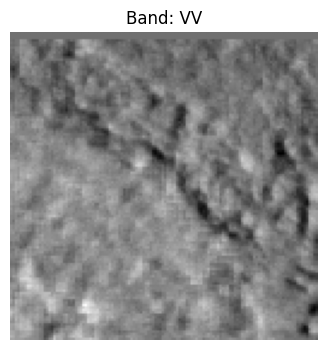

Map(center=[35.235012820623496, -85.97692755445384], controls=(WidgetControl(options=['position', 'transparent…

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geemap, ee
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ---------- Load the .npy chip ----------
npy_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/train/chip_000001.npy"
chip_struct = np.load(npy_path)

# Convert structured array to regular 3D NumPy array
band_names = chip_struct.dtype.names
chip_array = np.stack([chip_struct[name] for name in band_names], axis=-1)

print("Chip shape:", chip_array.shape)
print("Band names:", band_names)

# ---------- Visualize first band ----------
plt.figure(figsize=(4, 4))
plt.imshow(chip_array[:, :, 0], cmap="gray")
plt.title(f"Band: {band_names[0]}")
plt.axis("off")
plt.show()

# ---------- Display on a Map ----------
PIXELS = 128
SCALE = 10
HALF_BUFFER = PIXELS * SCALE / 2
PERCENTAGE = 10
IDX = 1  # chip_000001 index

sampled_train = (
    train_samp.randomColumn("rnd", seed=42)
              .filter(f"rnd < {PERCENTAGE / 100.0}")
)

geom_list = sampled_train.aggregate_array(".geo").getInfo()
chip_geom = ee.Geometry(geom_list[IDX])
chip_reg = chip_geom.centroid(maxError=1).buffer(HALF_BUFFER).bounds()

m = geemap.Map()
m.addLayer(chip_reg, {"color": "red"}, "chip_000001 footprint")
m.centerObject(chip_reg, 11)
display(m)


xxxxxx

In [ ]:
# training = geemap.ee_to_numpy(stacked, region=train_samp)
# print(training.shape)
# # print(training)

# testing = geemap.ee_to_numpy(stacked, region=test_samp)
# print(testing.shape)
# # print(testing)

# validation = geemap.ee_to_numpy(stacked, region=val_samp)
# print(validation.shape)
# # print(validation)

Prep target variables

In [18]:
y_stacked_fhd = GEDIindicesB_2021.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_fhd.bandNames())
Map.addLayer(y_stacked_fhd, {}, 'y_stacked_fhd')

y_stacked_ch = GEDIindicesA_2021.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_ch.bandNames())
Map.addLayer(y_stacked_ch, {}, 'y_stacked_ch')

y_stacked_pai = GEDIindicesB_2021.select("pai")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_pai.bandNames())
Map.addLayer(y_stacked_pai, {}, 'y_stacked_pai')


Map


ee.List({
  "functionInvocationValue": {
    "functionName": "Image.bandNames",
    "arguments": {
      "image": {
        "functionInvocationValue": {
          "functionName": "Image.select",
          "arguments": {
            "bandSelectors": {
              "constantValue": [
                "fhd_normal"
              ]
            },
            "input": {
              "functionInvocationValue": {
                "functionName": "Image.load",
                "arguments": {
                  "id": {
                    "constantValue": "projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021"
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})
ee.List({
  "functionInvocationValue": {
    "functionName": "Image.bandNames",
    "arguments": {
      "image": {
        "functionInvocationValue": {
          "functionName": "Image.select",
          "arguments": {
            "bandSelectors": {
       

Map(bottom=812.0, center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Search…

In [21]:
# ================================================================
# BLOCK – create target chips for y_fhd, y_ch, y_pai
# ================================================================
import ee, os, requests, shutil, multiprocessing
from retry import retry

# ------------ parameters you may change -------------------------
PIXELS      = 128          # chip width / height
SCALE       = 10           # metres per pixel
PERCENTAGE  = 0.1          # % of features to keep
N_WORKERS   = 12           # parallel download processes
BASE_DIR    = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee"
# ----------------------------------------------------------------
DIMENSIONS  = f"{PIXELS}x{PIXELS}"
HALF_BUFFER = PIXELS * SCALE / 2

# ------------ target stacks dictionary --------------------------
target_stacks = {
    "y_fhd": y_stacked_fhd,
    "y_ch": y_stacked_ch,
    "y_pai": y_stacked_pai
}

# ------------ helpers -------------------------------------------
def get_geoms(fc):
    """Return client-side list of GeoJSON geometries."""
    return fc.aggregate_array(".geo").getInfo()

@retry(tries=10, delay=1, backoff=2)
def download_chip(idx, geom, out_dir, stack, prefix="chip_"):
    """Download one NPY chip centred on *geom*."""
    region = ee.Geometry(geom).centroid(maxError=1).buffer(HALF_BUFFER).bounds()
    url    = stack.getDownloadURL({
        "region": region,
        "dimensions": DIMENSIONS,
        "format": "NPY"
    })
    r = requests.get(url, stream=True)
    r.raise_for_status()
    fn = os.path.join(out_dir, f"{prefix}{str(idx).zfill(6)}.npy")
    with open(fn, "wb") as fp:
        shutil.copyfileobj(r.raw, fp)

def process_set(fc, name, stack, subfolder):
    """Sample, prompt, download chips for a given set and target stack."""
    # Sample PERCENTAGE % reproducibly
    sampled = (fc.randomColumn("rnd", seed=42)
                 .filter(f"rnd < {PERCENTAGE / 100.0}"))
    n = sampled.size().getInfo()
    print(f"\n{(subfolder + ' / ' + name).upper()} → {n} chips will be created "
          f"({PERCENTAGE}% of original).")
    if input("Type 'y' + <Enter> to proceed: ").lower() != "y":
        print("Skipped.")
        return

    out_dir = os.path.join(BASE_DIR, subfolder, name)
    os.makedirs(out_dir, exist_ok=True)

    geoms = get_geoms(sampled)
    pool = multiprocessing.Pool(N_WORKERS)
    pool.starmap(download_chip, [(i, g, out_dir, stack) for i, g in enumerate(geoms)])
    pool.close(); pool.join()
    print(f"✓  {n} chips written → {out_dir}")

# ------------ run all targets for all sets -----------------------
SETS = {"y_train": train_samp, "y_test": test_samp, "y_val": val_samp}

for subfolder, stack in target_stacks.items():
    for set_name, fc in SETS.items():
        process_set(fc, set_name, stack, subfolder)



Y_FHD / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_fhd/y_train

Y_FHD / Y_TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_fhd/y_test

Y_FHD / Y_VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_fhd/y_val

Y_CH / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_ch/y_train

Y_CH / Y_TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_ch/y_test

Y_CH / Y_VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_ch/y_val

Y_PAI / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_pai/y_train

Y_PAI / Y_TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_pai/y_test

Y_PAI / Y_VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_pai/y_val


In [ ]:
# #y_stacked_fhd

# y_training_fhd = geemap.ee_to_numpy(y_stacked_fhd, region=train_samp)
# print(y_training_fhd.shape)
# # print(validation)

# y_testing_fhd = geemap.ee_to_numpy(y_stacked_fhd, region=test_samp)
# print(y_testing_fhd.shape)
# # print(validation)

# y_validation_fhd = geemap.ee_to_numpy(y_stacked_fhd, region=val_samp)
# print(y_validation_fhd.shape)
# # print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
# #y_stacked_ch

# y_training_ch = geemap.ee_to_numpy(y_stacked_ch, region=train_samp)
# print(y_training_ch.shape)
# # print(validation)

# y_testing_ch = geemap.ee_to_numpy(y_stacked_ch, region=test_samp)
# print(y_testing_ch.shape)
# # print(validation)

# y_validation_ch = geemap.ee_to_numpy(y_stacked_ch, region=val_samp)
# print(y_validation_ch.shape)
# # print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
# #y_stacked_pai

# y_training_pai= geemap.ee_to_numpy(y_stacked_pai, region=train_samp)
# print(y_training_pai.shape)
# # print(validation)

# y_testing_pai = geemap.ee_to_numpy(y_stacked_pai, region=test_samp)
# print(y_testing_pai.shape)
# # print(validation)

# y_validation_pai = geemap.ee_to_numpy(y_stacked_pai, region=val_samp)
# print(y_validation_pai.shape)
# # print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


Chip shape: (128, 128, 1)
Band names: ('fhd_normal',)


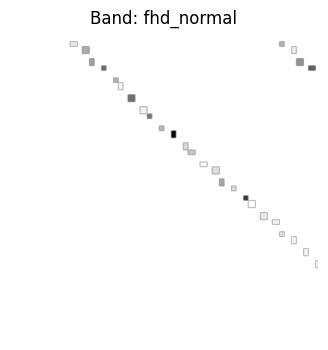

Map(center=[35.235012820623496, -85.97692755445384], controls=(WidgetControl(options=['position', 'transparent…

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geemap, ee
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ---------- Load the .npy chip ----------
npy_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee/y_fhd/y_train/chip_000001.npy"
chip_struct = np.load(npy_path)

# Convert structured array to regular 3D NumPy array
band_names = chip_struct.dtype.names
chip_array = np.stack([chip_struct[name] for name in band_names], axis=-1)

print("Chip shape:", chip_array.shape)
print("Band names:", band_names)

# ---------- Visualize first band ----------
plt.figure(figsize=(4, 4))
plt.imshow(chip_array[:, :, 0], cmap="gray")
plt.title(f"Band: {band_names[0]}")
plt.axis("off")
plt.show()

# ---------- Display on a Map ----------
PIXELS = 128
SCALE = 10
HALF_BUFFER = PIXELS * SCALE / 2
PERCENTAGE = 10
IDX = 1  # chip_000001 index

sampled_train = (
    train_samp.randomColumn("rnd", seed=42)
              .filter(f"rnd < {PERCENTAGE / 100.0}")
)

geom_list = sampled_train.aggregate_array(".geo").getInfo()
chip_geom = ee.Geometry(geom_list[IDX])
chip_reg = chip_geom.centroid(maxError=1).buffer(HALF_BUFFER).bounds()

m = geemap.Map()
m.addLayer(chip_reg, {"color": "red"}, "chip_000001 footprint")
m.centerObject(chip_reg, 11)
display(m)

# Block 1: Data Prep + Model Builders + Metrics Setup

In [41]:
# ================================================================
# BLOCK 1 – robust data loading & fusion model builders
# ================================================================
import os, glob, numpy as np, tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dropout, Concatenate, Add
from tensorflow.keras.models import Model

BASE = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee"

# ---------- helpers ------------------------------------------------
def _to_float_array(arr):
    if arr.dtype.names is not None:  # structured dtype → regular ndarray
        arr = np.stack([arr[name] for name in arr.dtype.names], axis=-1)
    return arr.astype(np.float32)

def sanitize(arr, clip_val=1e6):
    arr = _to_float_array(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=clip_val, neginf=-clip_val)
    return np.clip(arr, -clip_val, clip_val)

def load_xy(split, target):
    x_dir = os.path.join(BASE, split)
    y_dir = os.path.join(BASE, f"y_{target}", f"y_{split}")

    x_files = {os.path.basename(f): f for f in glob.glob(f"{x_dir}/*.npy")}
    y_files = {os.path.basename(f): f for f in glob.glob(f"{y_dir}/*.npy")}
    common  = sorted(x_files.keys() & y_files.keys())
    if not common:
        raise ValueError(f"No common chips for {split}/{target}")

    X, y = [], []
    for fn in common:
        X.append(sanitize(np.load(x_files[fn])))
        y.append(sanitize(np.load(y_files[fn])))
    return np.stack(X), np.stack(y)

# ---------- determine band-count once -----------------------------
X_train_full, _ = load_xy("train", "fhd")
N_BANDS = X_train_full.shape[-1]

# ---------- optional per-band scaling -----------------------------
def scale_inputs(X_train, *others):
    mins = X_train.reshape(-1, N_BANDS).min(0)
    maxs = X_train.reshape(-1, N_BANDS).max(0)
    maxs[maxs == mins] += 1e-6
    def _f(a): return ((a - mins) / (maxs - mins)).astype(np.float32)
    return (_f(X_train),) + tuple(_f(o) for o in others)

# ---------- band slices -------------------------------------------
SAR_SLICE, DEM_SLICE = slice(0, 8), slice(8, 10)
LAND_SLICE, S2_SLICE = slice(10, 33), slice(33, N_BANDS)
N_S2 = N_BANDS - 33
def split_inputs(X):
    return (X[..., SAR_SLICE],
            X[..., DEM_SLICE],
            X[..., LAND_SLICE],
            X[..., S2_SLICE])

# ---------- fusion model builders ---------------------------------
def build_early_fusion(input_shape=(128,128,N_BANDS), filters=32,
                       kernel_size=(3,3), dropout=0.0):
    inp = Input(shape=input_shape)
    x   = Conv2D(filters, kernel_size, activation='relu', padding='same')(inp)
    x   = Dropout(dropout)(x)
    x   = Conv2D(filters*2, kernel_size, activation='relu', padding='same')(x)
    out = Conv2D(1,(1,1),activation='linear',padding='same')(x)
    return Model(inp, out)

def _blk(shape, f, k, dr):
    i = Input(shape=shape)
    x = Conv2D(f, k, activation='relu', padding='same')(i)
    x = Dropout(dr)(x)
    x = Conv2D(f*2, k, activation='relu', padding='same')(x)
    return i, x

def build_mid_fusion(filters=32, kernel_size=(3,3), dropout=0.0):
    i1,x1=_blk((128,128,8),   filters,kernel_size,dropout)
    i2,x2=_blk((128,128,2),   filters,kernel_size,dropout)
    i3,x3=_blk((128,128,23),  filters,kernel_size,dropout)
    i4,x4=_blk((128,128,N_S2),filters,kernel_size,dropout)
    cat = Concatenate()([x1,x2,x3,x4])
    cat = Conv2D(64,(3,3),activation='relu',padding='same')(cat)
    out = Conv2D(1,(1,1),activation='linear',padding='same')(cat)
    return Model([i1,i2,i3,i4], out)

def build_late_fusion(filters=32, kernel_size=(3,3), dropout=0.0):
    def bl(shape):
        i,x=_blk(shape,filters,kernel_size,dropout)
        x=Conv2D(1,(1,1),activation='linear',padding='same')(x)
        return i,x
    i1,y1=bl((128,128,8));  i2,y2=bl((128,128,2))
    i3,y3=bl((128,128,23)); i4,y4=bl((128,128,N_S2))
    add  = Add()([y1,y2,y3,y4])
    out  = Conv2D(1,(1,1),activation='linear',padding='same')(add)
    return Model([i1,i2,i3,i4], out)


# Block 2: Hyperparameter Grid Search + Logging

In [ ]:
# ================================================================
# BLOCK 2 – Grid-search, evaluation, *and* results capture
# ================================================================
import numpy as np, pandas as pd
from itertools import product
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

grid_vals = {
    'filters': [32],
    'dropout': [0.0],
    'lr':      [1e-3],
}

def run_exp(model_fn, X, y, fusion_name, target_name):
    """Grid-search for ONE fusion builder & ONE target – returns best model & DataFrame."""
    records, best_loss, best_cfg, best_model = [], np.inf, None, None

    for f, dr, lr in product(grid_vals['filters'],
                             grid_vals['dropout'],
                             grid_vals['lr']):
        cfg = {'filters': f, 'dropout': dr, 'lr': lr}
        model = model_fn(filters=f, dropout=dr)
        model.compile(optimizer=Adam(lr), loss='mse')
        model.fit(X, y, epochs=3, batch_size=4, verbose=0,
                  callbacks=[EarlyStopping(patience=1)])
        loss = model.evaluate(X, y, verbose=0)

        # store record
        records.append({
            'target'      : target_name,
            'fusion_type' : fusion_name,
            'filters'     : f,
            'dropout_rate': dr,
            'learning_rate': lr,
            'mse'         : loss,
            'rmse'        : np.sqrt(loss),
            'mae'         : np.nan,      # can fill if needed
            'r2'          : np.nan       # can fill if needed
        })

        if loss < best_loss:
            best_loss, best_cfg, best_model = loss, cfg, model

    return best_model, best_cfg, pd.DataFrame(records)

# ------------- run for all targets & fusions --------------------
all_results_frames = []

for tgt in ["fhd", "ch", "pai"]:
    print(f"\n### TARGET: {tgt.upper()} ###")
    X_tr, y_tr = load_xy("train", tgt)
    X_te, y_te = load_xy("test",  tgt)

    # OPTIONAL: scale
    X_tr, X_te = scale_inputs(X_tr, X_te)

    # Early
    best_early_model, best_early_params, df_e = run_exp(
        build_early_fusion, X_tr, y_tr, "Early Fusion", tgt)
    all_results_frames.append(df_e)

    # Mid
    best_mid_model, best_mid_params, df_m = run_exp(
        build_mid_fusion, split_inputs(X_tr), y_tr, "Mid Fusion", tgt)
    all_results_frames.append(df_m)

    # Late
    best_late_model, best_late_params, df_l = run_exp(
        build_late_fusion, split_inputs(X_tr), y_tr, "Late Fusion", tgt)
    all_results_frames.append(df_l)

    # quick test MSEs
    def mse_on_test(mdl, X_in):
        p = mdl.predict(X_in, verbose=0)
        return mean_squared_error(y_te.flatten(), p.flatten())
    print(" Early test MSE:", mse_on_test(best_early_model, X_te))
    print("   Mid test MSE:", mse_on_test(best_mid_model,  split_inputs(X_te)))
    print("  Late test MSE:", mse_on_test(best_late_model, split_inputs(X_te)))

# ------------ combine & persist results -------------------------
all_results = pd.concat(all_results_frames, ignore_index=True)
all_results.to_csv("hyperparameter_results.csv", index=False)
print("\nSaved results → hyperparameter_results.csv")



### TARGET: FHD ###
 Early test MSE: 977675878400.0
   Mid test MSE: 944509026304.0
  Late test MSE: 978022563840.0

### TARGET: CH ###


# Block 3: Save Results + Plot + Visualize Best Model

In [ ]:
# ================================================================
# BLOCK 3 – Visualise hyper-param results & save best models
# ================================================================
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# ---------- load results table ----------
try:
    all_results
except NameError:
    all_results = pd.read_csv("hyperparameter_results.csv")

# ---------- tidy up / derive columns ----------
if 'kernel_size' in all_results.columns:
    all_results['kernel_size_num'] = all_results['kernel_size'].apply(
        lambda x: int(str(x).strip('()').split(',')[0])
    )

metrics_cols = ['mse', 'rmse', 'mae', 'r2']
param_cols   = ['filters', 'kernel_size_num', 'dropout_rate', 'learning_rate']

# ---------- pair-plot ----------
sns.pairplot(all_results, vars=[c for c in metrics_cols if c in all_results],
             hue='fusion_type')
plt.suptitle("Pair-plot of Metrics by Fusion Type", y=1.02)
plt.show()

# ---------- box-plots ----------
for metric in metrics_cols:
    if metric not in all_results: continue
    for param in param_cols:
        if param in all_results:
            plt.figure(figsize=(8,5))
            sns.boxplot(x=param, y=metric, hue='fusion_type', data=all_results)
            plt.title(f'{metric.upper()} vs {param}')
            plt.show()

# ---------- correlation heat-map ----------
corr_cols = [c for c in param_cols if c in all_results] + \
            [c for c in metrics_cols if c in all_results]
plt.figure(figsize=(10,8))
sns.heatmap(all_results[corr_cols].corr(), annot=True, fmt=".2f",
            cmap='coolwarm')
plt.title("Correlation Heat-map: Parameters ↔ Metrics")
plt.show()

# ---------- print & save best models ----------
print("\n» Best Early params:", best_early_params)
print("» Best Mid  params:", best_mid_params)
print("» Best Late params:", best_late_params)

best_early_model.summary()
best_early_model.save("best_early_model.h5")

best_mid_model.summary()
best_mid_model.save("best_mid_model.h5")

best_late_model.summary()
best_late_model.save("best_late_model.h5")

print("\nAll done ✔")


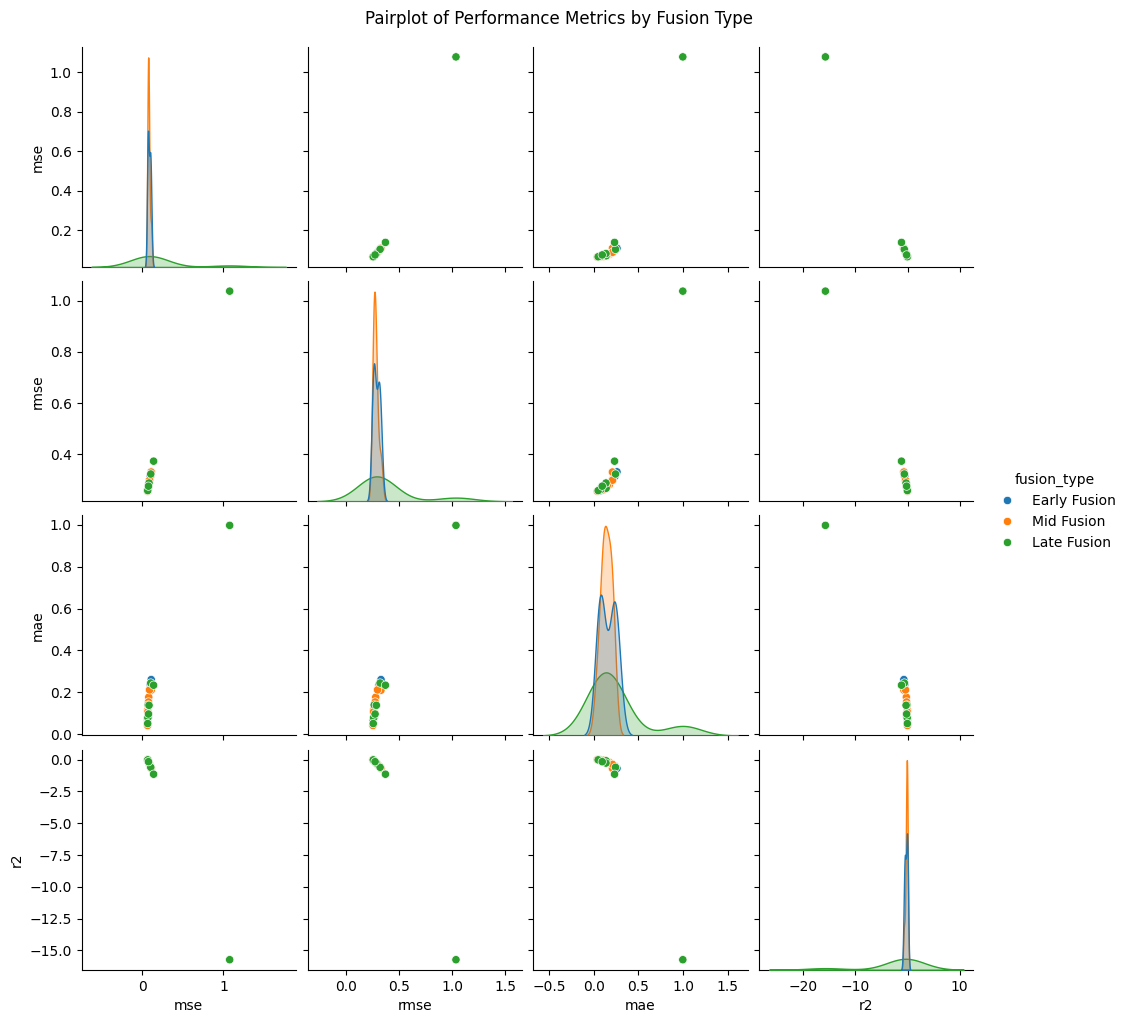

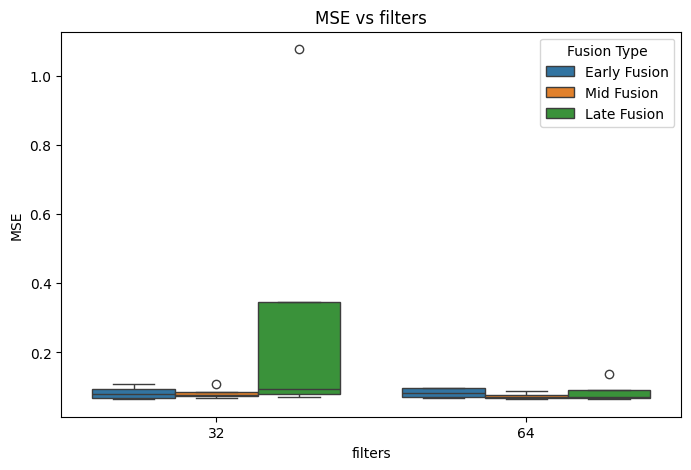

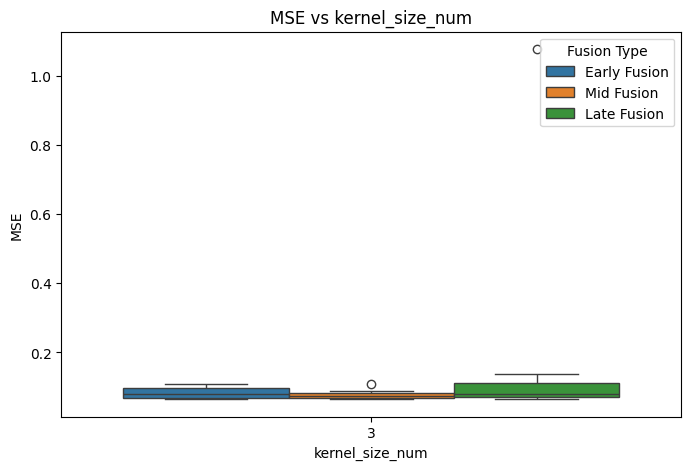

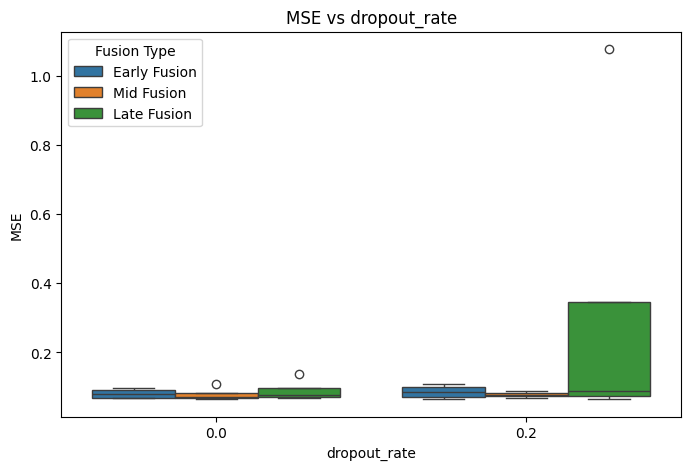

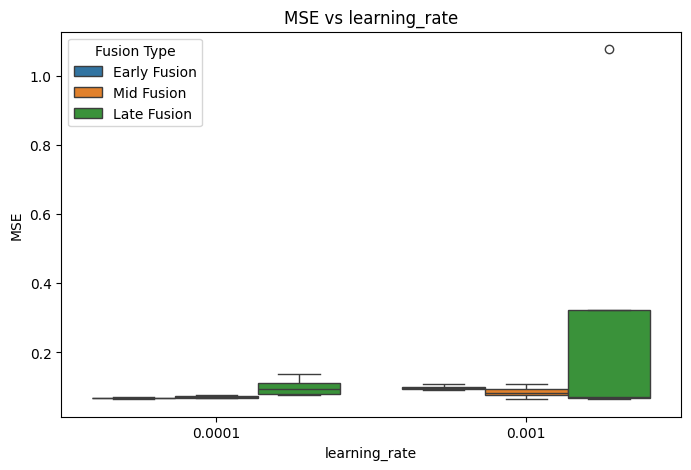

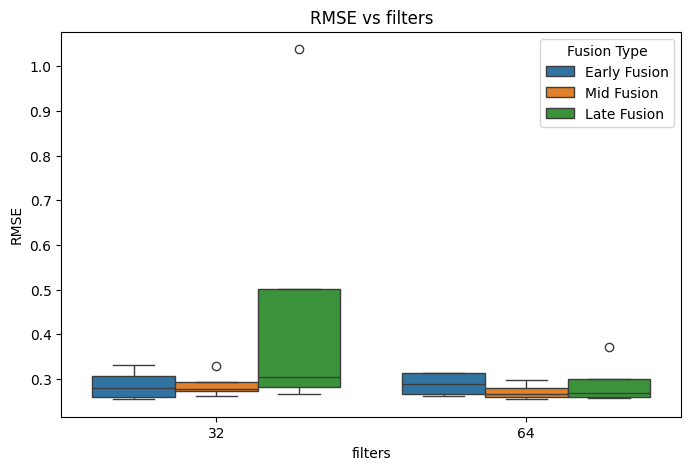

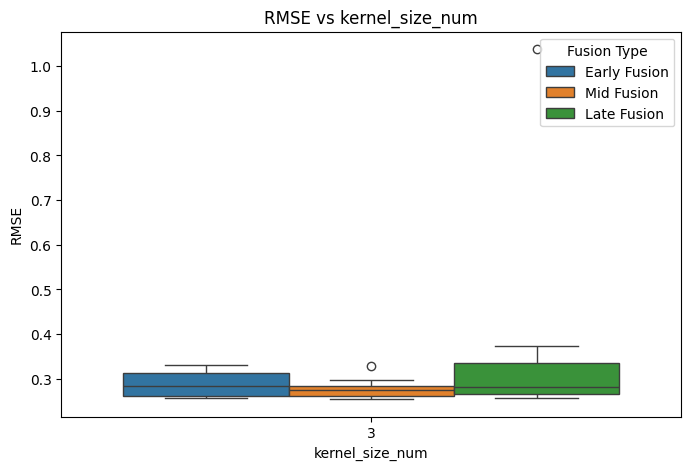

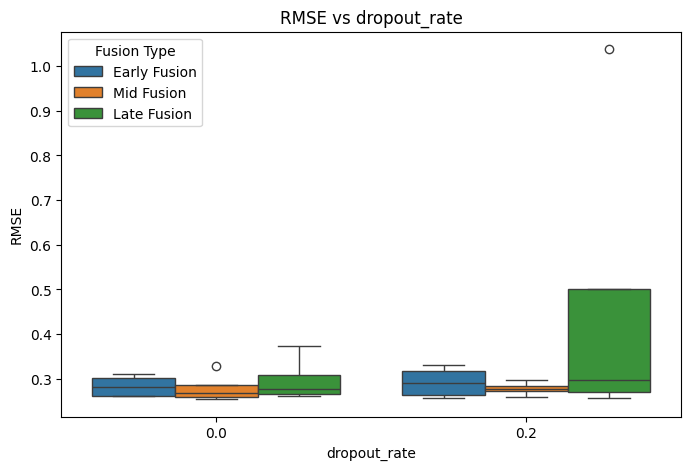

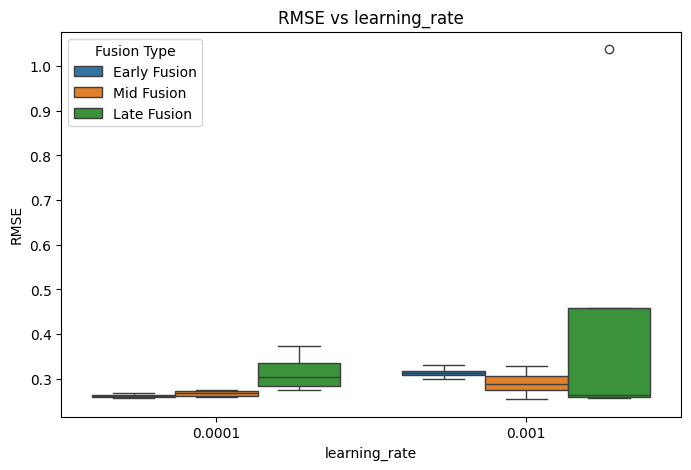

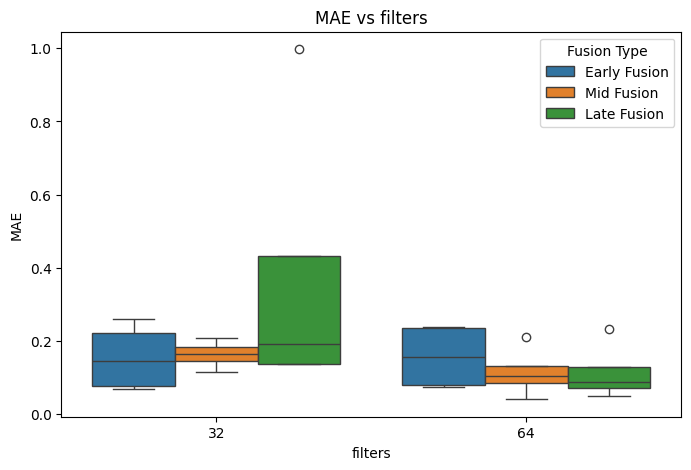

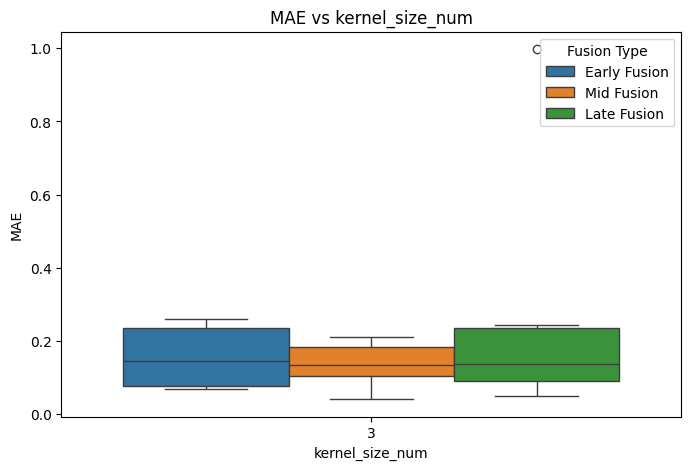

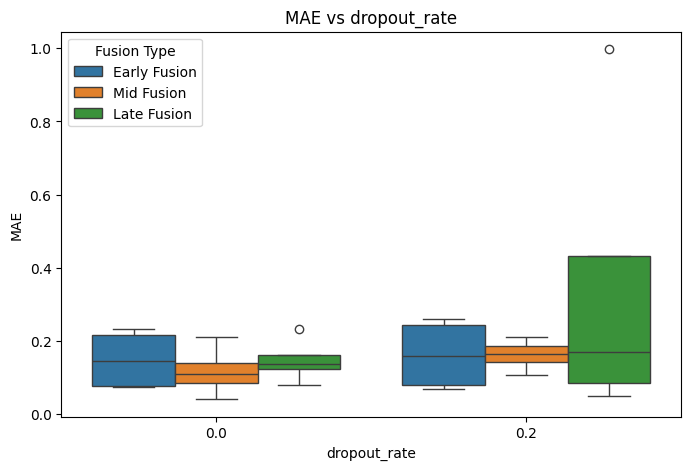

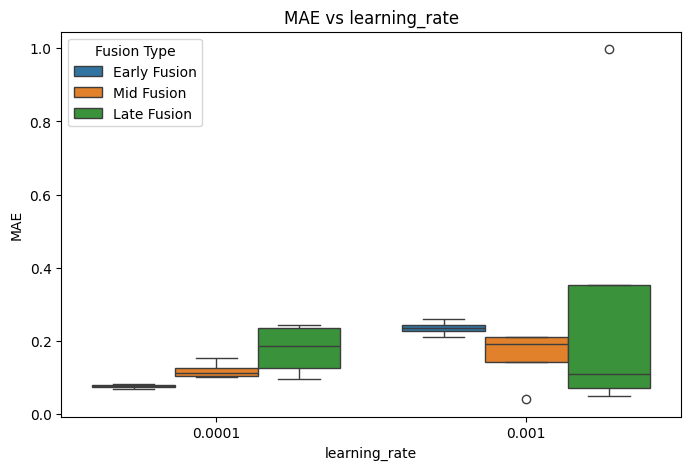

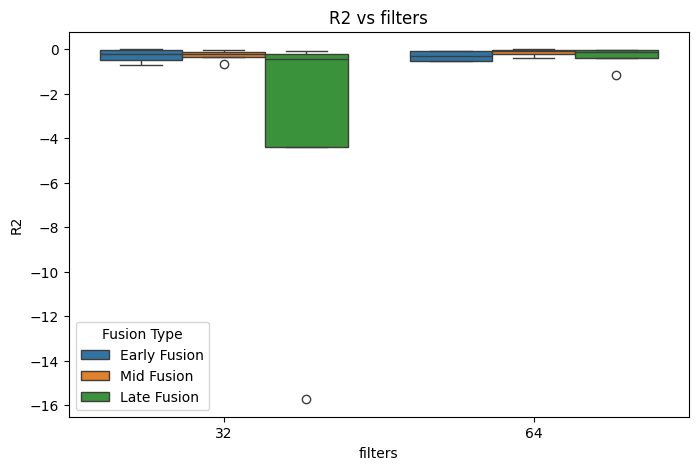

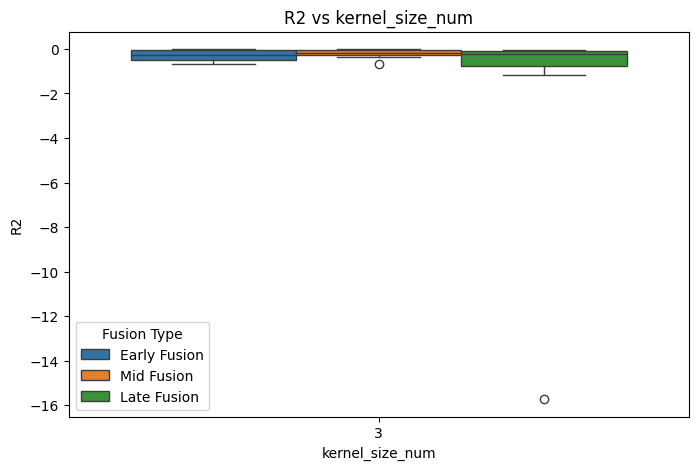

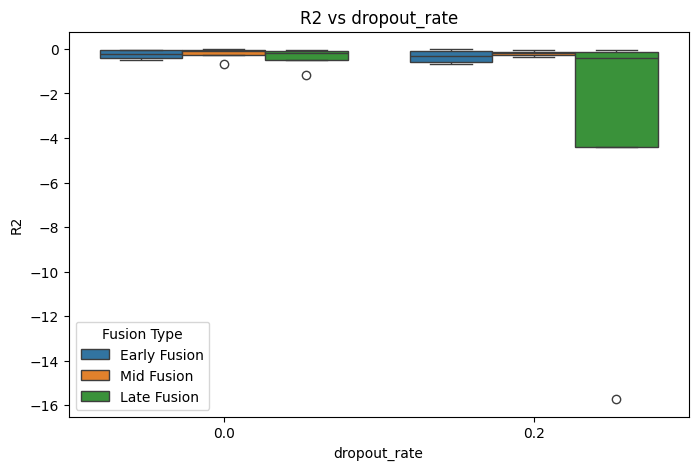

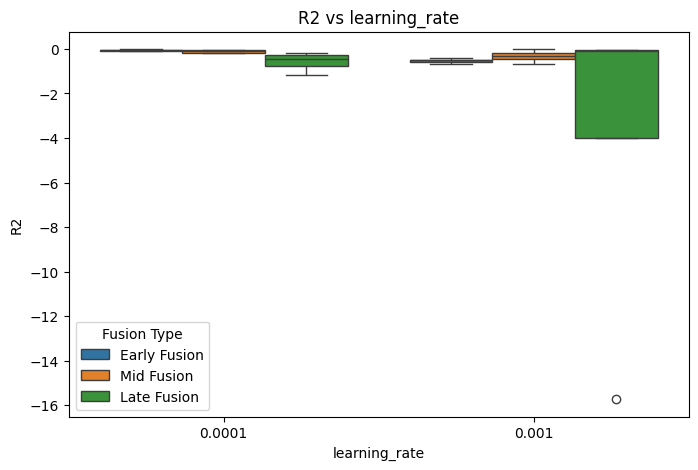

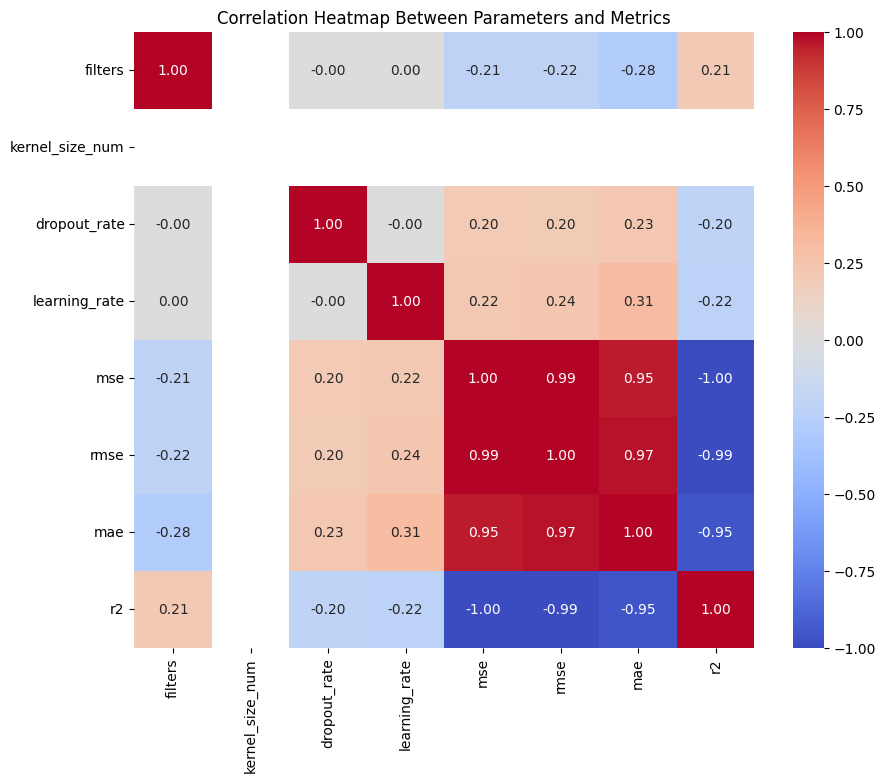

Best Early Fusion Params: {'filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.0, 'learning_rate': 0.001, 'input_shape': (103, 107, 45)}
Best Mid Fusion Params: {'filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.0, 'learning_rate': 0.001}
Best Late Fusion Params: {'filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.2, 'learning_rate': 0.001}
best_late_model.summary()


Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_148 (InputLayer)    │ (None, 103, 107, 45)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_364 (Conv2D)             │ (None, 103, 107, 64)   │        25,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_148 (Dropout)           │ (None, 103, 107, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_365 (Conv2D)             │ (None, 103, 107, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_100 (Cropping2D)     │ (None, 103, 103, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_366 (Conv2D)             │ (None, 103, 103, 1)    │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,909 (1.14 MB)

 Trainable params: 99,969 (390.50 KB)

...

 Total params: 79,316 (309.83 KB)

 Trainable params: 26,438 (103.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,878 (206.56 KB)

complete


In [ ]:
# import seaborn as sns
# import pandas as pd
# import matplotlib.pyplot as plt

# # --- Load results (if not already in memory) ---
# all_results = pd.read_csv("hyperparameter_results.csv")

# # --- Convert kernel_size (tuple) to just one numeric value (e.g., first element) ---
# if 'kernel_size' in all_results.columns:
#     all_results['kernel_size_num'] = all_results['kernel_size'].apply(lambda x: int(str(x).strip('()').split(',')[0]))

# # --- Seaborn pairplot for metrics ---
# metrics_cols = ['mse', 'rmse', 'mae', 'r2']
# sns.pairplot(all_results, vars=metrics_cols, hue='fusion_type')
# plt.suptitle("Pairplot of Performance Metrics by Fusion Type", y=1.02)
# plt.show()

# # --- Compare metrics vs model parameters ---
# param_cols = ['filters', 'kernel_size_num', 'dropout_rate', 'learning_rate']
# for metric in metrics_cols:
#     for param in param_cols:
#         if param in all_results.columns:
#             plt.figure(figsize=(8, 5))
#             sns.boxplot(x=param, y=metric, hue='fusion_type', data=all_results)
#             plt.title(f'{metric.upper()} vs {param}')
#             plt.xlabel(param)
#             plt.ylabel(metric.upper())
#             plt.legend(title='Fusion Type')
#             plt.show()

# # --- Correlation heatmap between parameters and metrics ---
# corr_cols = [col for col in param_cols if col in all_results.columns] + metrics_cols
# corr_matrix = all_results[corr_cols].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Heatmap Between Parameters and Metrics')
# plt.show()

# # --- Print best models ---
# print("Best Early Fusion Params:", best_early_params)
# print("Best Mid Fusion Params:", best_mid_params)
# print("Best Late Fusion Params:", best_late_params)

# # --- Visualize best model architecture ---
# print("best_late_model.summary()")
# best_early_model.summary()
# best_early_model.save('best_early_model.h5')

# print("best_mid_model.summary()")
# best_mid_model.summary()
# best_mid_model.save('best_mid_model.h5')

# print("best_late_model.summary()")
# best_late_model.summary()
# best_late_model.save('best_late_model.h5')

# print("complete")


In [ ]:
# STEP 1: Install dependencies
!apt-get update
!apt-get install texlive-latex-base texlive-fonts-recommended texlive-fonts-extra texlive-latex-extra dvipng cm-super imagemagick -y

# # STEP 2: Clone PlotNeuralNet repo
# !git clone https://github.com/HarisIqbal88/PlotNeuralNet.git

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,212 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,546 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages 

In [ ]:
# %rm -r /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/*

This does work, but makes tree level figures

In [ ]:
import os
import subprocess

# --- Paths ---
tex_gen_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet/pyexamples/latex_generate.py'
output_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images'
base_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet'

# --- Helper to write tex description ---
def write_tex_file(model_name, model):
    from tensorflow.keras.utils import plot_model
    plot_path = os.path.join(base_path, f"{model_name}.png")
    plot_model(model, to_file=plot_path, show_shapes=True)
    return plot_path

# --- Generate LaTeX architecture image ---
def generate_plot_neural_net(model_name, model):
    tex_file_path = write_tex_file(model_name, model)

    # You must have LaTeX and ImageMagick installed in the colab/session
    os.chdir(base_path)
    tex_src = f"{model_name}.tex"

    # Build a dummy tex file from a prewritten template or manually build it
    with open(tex_src, 'w') as f:
        f.write(r"""
\documentclass[border=8pt]{standalone}
\usepackage{import}
\subimport{./}{preamble.tex}
\begin{document}
\input{examples/""" + model_name + r"""}
\end{document}
""")

    # Compile LaTeX to PDF
    subprocess.run(['pdflatex', tex_src], stdout=subprocess.PIPE)

    # Convert PDF to JPG
    pdf_path = os.path.join(base_path, f"{model_name}.pdf")
    jpg_path = os.path.join(output_dir, f"{model_name}.jpg")
    subprocess.run(['convert', '-density', '300', pdf_path, '-quality', '90', jpg_path])

    print(f"Saved {model_name} architecture visualization at {jpg_path}")

# --- Create visualizations ---
generate_plot_neural_net("early_fusion_model", best_early_model)
generate_plot_neural_net("mid_fusion_model", best_mid_model)
generate_plot_neural_net("late_fusion_model", best_late_model)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet/early_fusion_model.png'

xxxxxxxxxxxxxxxxx

In [ ]:
# %rm -r /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet/*

In [ ]:
# %rm -r /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/*

In [ ]:
import os
from tensorflow.keras.models import load_model

def export_model_to_plotnn_tex(model, tex_path, model_name="model"):
    os.makedirs(os.path.dirname(tex_path), exist_ok=True)

    with open(tex_path, "w") as f:
        f.write(r"""\documentclass[border=8pt, multi, tikz]{standalone}
\usepackage{import}
\subimport{../../PlotNeuralNet/}{tikz_commands.tex}
\begin{document}
\begin{tikzpicture}[
    x=1.5cm, y=1.5cm, z=0.6cm,
    every node/.style={scale=0.9}
]
""")
        # --- Define nodes from model ---
        prev = None
        for layer in model.layers:
            name = layer.name
            layer_type = layer.__class__.__name__

            if "Input" in layer_type:
                style = "inputlayer"
            elif "Conv" in layer_type:
                style = "conv"
            elif "Dropout" in layer_type:
                style = "dropout"
            elif "Add" in layer_type or "Concatenate" in layer_type:
                style = "eltwise"
            elif "Cropping" in layer_type:
                style = "softmax"  # Placeholder
            else:
                style = "softmax"

            if prev is None or style == "inputlayer":
                f.write(f"\\node[{style}] ({name}) at (0, 0, 0) {{}};\n")
            else:
                f.write(f"\\node[{style}, right=of {prev}] ({name}) {{}};\n")
            prev = name

        f.write(r"""\end{tikzpicture}
\end{document}
""")
    print(f"Saved TikZ .tex for {model_name} to {tex_path}")

# --- Load best models WITHOUT compilation ---
early_model_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/best_early_model.h5"
mid_model_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/best_mid_model.h5"
late_model_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/best_late_model.h5"

best_early_model = load_model(early_model_path, compile=False)
best_mid_model = load_model(mid_model_path, compile=False)
best_late_model = load_model(late_model_path, compile=False)

# --- Export to LaTeX (PlotNeuralNet style) ---
output_dir = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images"

export_model_to_plotnn_tex(best_early_model, os.path.join(output_dir, "early_fusion.tex"), "early_fusion")
export_model_to_plotnn_tex(best_mid_model, os.path.join(output_dir, "mid_fusion.tex"), "mid_fusion")
export_model_to_plotnn_tex(best_late_model, os.path.join(output_dir, "late_fusion.tex"), "late_fusion")


Saved TikZ .tex for early_fusion to /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/early_fusion.tex
Saved TikZ .tex for mid_fusion to /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/mid_fusion.tex
Saved TikZ .tex for late_fusion to /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/late_fusion.tex


In [ ]:
!apt-get install texlive-full -y
!apt-get install imagemagick -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  aglfn asymptote asymptote-doc biber chktex context context-modules cups-bsd
  cups-client cups-common dvidvi feynmf fonts-arphic-bkai00mp
  fonts-arphic-bsmi00lp fonts-arphic-gbsn00lp fonts-arphic-gkai00mp
  fonts-arphic-uming fonts-baekmuk fonts-gfs-baskerville
  fonts-gfs-bodoni-classic fonts-gfs-didot-classic fonts-gfs-gazis
  fonts-gfs-porson fonts-gfs-theokritos fonts-hosny-amiri
  fonts-ipaexfont-gothic fonts-ipaexfont-mincho fonts-ipafont-gothic
  fonts-ipafont-mincho fonts-sil-padauk fonts-tlwg-garuda
  fonts-tlwg-garuda-otf fonts-tlwg-kinnari fonts-tlwg-kinnari-otf
  fonts-tlwg-laksaman fonts-tlwg-laksaman-otf fonts-tlwg-loma
  fonts-tlwg-loma-otf fonts-tlwg-mono fonts-tlwg-mono-otf fonts-tlwg-norasi
  fonts-tlwg-norasi-otf fonts-tlwg-purisa fonts-tlwg-purisa-otf
  fonts-tlwg-sawasdee fonts-tlwg-sawasdee-otf fonts-tlwg-typewrit

In [ ]:
import os
import subprocess

# --- Set paths ---
tex_file = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/early_fusion.tex"
tex_dir = os.path.dirname(tex_file)
tex_filename = os.path.basename(tex_file)
output_basename = os.path.splitext(tex_filename)[0]

# --- Change working directory ---
os.chdir(tex_dir)

# --- Compile LaTeX to PDF ---
subprocess.run(["pdflatex", tex_filename], check=True)

# --- Convert PDF to PNG (optional) ---
pdf_file = os.path.join(tex_dir, f"{output_basename}.pdf")
png_file = os.path.join(tex_dir, f"{output_basename}.png")
subprocess.run(["convert", "-density", "300", pdf_file, "-quality", "90", png_file], check=True)

print(f"✔ Visualization saved to: {png_file}")


XXXXXXXXXXXXXX
https://github.com/paulgavrikov/visualkeras/

In [ ]:
!pip install visualkeras

In [ ]:
import visualkeras

model = best_early_model

visualkeras.layered_view(model).show() # display using your system viewer
visualkeras.layered_view(model, to_file='output.png') # write to disk
visualkeras.layered_view(model, to_file='output.png').show() # write and show

#Block 4 Reproject and export predicitons

In [ ]:
import tifffile as tiff
import os

# Create output directory if it doesn't exist
# directory_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/fusion_predictions_tifs"
# os.mkdir(directory_path)

output_dir = 'fusion_predictions_tifs'
os.makedirs(output_dir, exist_ok=True)

# Generate predictions
early_pred = best_early_model.predict(X_test)
mid_pred = best_mid_model.predict([SAR_test, DEM_test, Landsat_test, Sentinel_test])
late_pred = best_late_model.predict([SAR_test, DEM_test, Landsat_test, Sentinel_test])

# Save as TIFF files (only first sample, or loop if you want all)
tiff.imwrite(os.path.join(output_dir, 'early_fusion_prediction.tif'), early_pred[0, :, :, 0])
tiff.imwrite(os.path.join(output_dir, 'mid_fusion_prediction.tif'), mid_pred[0, :, :, 0])
tiff.imwrite(os.path.join(output_dir, 'late_fusion_prediction.tif'), late_pred[0, :, :, 0])

print(f"TIFF files saved in folder: {output_dir}")


Usign GEE orginal image as reference

In [ ]:
import ee
import geemap
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os
import glob

# # Initialize Earth Engine
# ee.Initialize()

# Load the reference GEE image
reference_image = ee.Image("projects/servir-sco-assets/assets/PR/s1Ascending_2022")

# Get projection details from the reference image
proj = reference_image.projection()
crs = proj.crs().getInfo()
scale = proj.nominalScale().getInfo()

# Get the bounds (region) from the reference image
bounds = reference_image.geometry().bounds().coordinates().getInfo()[0]

# Extract upper-left corner and calculate width/height in degrees
ulx = min([pt[0] for pt in bounds])
lrx = max([pt[0] for pt in bounds])
uly = max([pt[1] for pt in bounds])
lry = min([pt[1] for pt in bounds])

# Calculate pixel size in degrees
width = 103
height = 103
xres = (lrx - ulx) / width
yres = (uly - lry) / height

# Prepare the transform
transform = from_origin(ulx, uly, abs(xres), abs(yres))

# Define input and output directories
input_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/fusion_predictions_tifs'
output_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions'

# Make sure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Find all .tif files in the input directory
tif_files = glob.glob(os.path.join(input_dir, '*.tif'))

# Process each TIFF file
for tif_file in tif_files:
    # Load the predicted array
    with rasterio.open(tif_file) as src:
        data = src.read(1)  # assuming single-band
        # Optionally, squeeze if you expect shape (1, 1, 103, 103, 1)
        data = np.squeeze(data)

    # Check dimensions, resample if needed
    if data.shape != (103, 103):
        print(f"Warning: {os.path.basename(tif_file)} has shape {data.shape}, expected (103, 103). Skipping.")
        continue

    # Define output filename
    output_filename = os.path.basename(tif_file).replace('.tif', '_reproj.tif')
    output_path = os.path.join(output_dir, output_filename)

    # Write the GeoTIFF
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,  # single band
        dtype=data.dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(data, 1)

    print(f"Saved reprojected file: {output_path}")

print("Batch processing completed.")


Back-up if you need to manually reporject the tiff

In [ ]:
# import numpy as np
# import rasterio
# from rasterio.transform import from_origin

# # Example input (your prediction array)
# array_2d = np.squeeze(early_pred)  # Shape becomes (103, 103)

# # Upper-left and lower-right coordinates (in degrees)
# ulx = -66.88492974621839
# uly = 17.968731133657553
# lrx = -66.87537229630139
# lry = 17.95952393838524

# # Grid size
# width = 103
# height = 103

# # Calculate pixel size in degrees
# xres = (lrx - ulx) / width
# yres = (lry - uly) / height  # negative for north-up rasters

# # Define transform (note: from_origin uses positive yres; we provide abs)
# transform = from_origin(ulx, uly, abs(xres), abs(yres))

# # Define output path
# output_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'

# # Write the GeoTIFF
# with rasterio.open(
#     output_path,
#     'w',
#     driver='GTiff',
#     height=height,
#     width=width,
#     count=1,  # single band
#     dtype=array_2d.dtype,
#     crs='EPSG:4326',
#     transform=transform
# ) as dst:
#     dst.write(array_2d, 1)

# print(f"GeoTIFF saved to {output_path}")


# Block 5: Independant Valdiation with Neon

Access clean and use NEON Veg site data: working notebook: https://github.com/MayerT1/LiDAR_Dev/blob/main/Neon_tree_height_and_Lidar_CHM.ipynb

Laz fecth and viz: https://github.com/MayerT1/LiDAR_Dev/blob/main/NEON_Discrete_Lidar_Data.ipynb

In [ ]:
import laspy
import numpy as np
import rasterio
from rasterio.transform import from_origin
from scipy.stats import entropy


In [ ]:
import os
# use os.path.join to get the full path of the laz file
laz_data_file=os.path.join("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/",'NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz')
# read the laz file into a LasData object using laspy.read()
point_cloud=laspy.read(laz_data_file)

In [ ]:
# import laspy
# import numpy as np
# import rasterio
# from rasterio.transform import from_origin
# from scipy.stats import entropy

# # Load LAZ file
# las = laspy.read("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz")

# # Extract data
# x = las.x
# y = las.y
# z = las.z
# classification = las.classification

# # Identify ground points
# ground_z = z[classification == 2]

# # Build ground surface (simple min height per (x, y))
# from scipy.spatial import cKDTree

# ground_coords = np.vstack((x[classification == 2], y[classification == 2])).T
# tree = cKDTree(ground_coords)
# _, idx = tree.query(np.vstack((x, y)).T, k=1)
# ground_heights = z[classification == 2][idx]

# # Compute height above ground (HAG)
# hag = z - ground_heights

# # Define grid parameters
# resolution = 1  # meters
# xmin, ymin, xmax, ymax = x.min(), y.min(), x.max(), y.max()
# ncols = int(np.ceil((xmax - xmin) / resolution))
# nrows = int(np.ceil((ymax - ymin) / resolution))
# print("ncols", ncols)
# print("nrows", nrows)

# # Initialize diversity grid
# diversity_grid = np.full((nrows, ncols), np.nan)
# print("diversity_grid", diversity_grid)
# # Define height bins
# bins = [0, 5, 10, 15, 20, np.inf]

# # Assign points to grid cells
# col_idx = ((x - xmin) / resolution).astype(int)
# row_idx = ((ymax - y) / resolution).astype(int)  # flip Y axis

# # Loop through each grid cell
# for r in range(nrows):
#     for c in range(ncols):
#         mask = (row_idx == r) & (col_idx == c) & (hag > 0)
#         if np.sum(mask) > 0:
#             cell_heights = hag[mask]
#             hist, _ = np.histogram(cell_heights, bins=bins)
#             hist = hist[hist > 0]
#             print("hist", hist)
#             if len(hist) > 1:
#                 shannon = entropy(hist, base=2)
#                 diversity_grid[r, c] = shannon
#                 print("diversity_grid shannon:", diversity_grid)
#             else:
#                 diversity_grid[r, c] = 0  # no diversity if only one bin filled

# # Save as GeoTIFF
# transform = from_origin(xmin, ymax, resolution, resolution)
# with rasterio.open(
#     'foliage_height_diversity.tif',
#     'w',
#     driver='GTiff',
#     height=nrows,
#     width=ncols,
#     count=1,
#     dtype=diversity_grid.dtype,
#     crs=las.header.parse_crs().to_wkt(),
#     transform=transform,
# ) as dst:
#     dst.write(diversity_grid, 1)

# print("Saved foliage_height_diversity.tif")


Run this R code to make Laz to FD product
https://r-lidar.github.io/lidRbook/itd.html


https://r-lidar.github.io/lidRbook/grid_metrics.html

In [ ]:
# activate R magic
%load_ext rpy2.ipython

In [ ]:
%%R

# Install required packages if missing
if (!requireNamespace("lidR", quietly = TRUE)) install.packages("lidR")
if (!requireNamespace("raster", quietly = TRUE)) install.packages("raster")

# Load libraries
library(lidR)
library(raster)

# Set file paths
laz_file <- "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz"
output_folder <- "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/lidar_metrics_outputs"

# Create output folder if it doesn't exist
if (!dir.exists(output_folder)) dir.create(output_folder)

# Read point cloud
las <- readLAS(laz_file)
if (is.empty(las)) stop("LAS file is empty!")

# Set grid resolution (in meters)
resolution <- 1  # increase if needed

# ------------------ #
# Create DTM and DSM
# ------------------ #
dtm <- rasterize_terrain(las, res = resolution, tin())
dsm <- rasterize_canopy(las, res = resolution, p2r())

# Compute CHM = DSM - DTM
chm <- dsm - dtm

# Save CHM raster
chm_path <- file.path(output_folder, "canopy_height_model_lidr.tif")
writeRaster(chm, chm_path, overwrite = TRUE)
cat("Saved CHM raster to:", chm_path, "\n")

# ------------------ #
# Normalize height (above ground) for FHD + PAI
# ------------------ #
las_norm <- normalize_height(las, dtm)

# ------------------ #
# 1️⃣ Foliage Height Diversity (FHD)
# ------------------ #
fhd_metrics <- pixel_metrics(las_norm, ~entropy(Z, by = 5), res = resolution)
fhd_raster <- raster(fhd_metrics)
fhd_path <- file.path(output_folder, "foliage_height_diversity_lidr.tif")
writeRaster(fhd_raster, fhd_path, overwrite = TRUE)
cat("Saved FHD raster to:", fhd_path, "\n")

# ------------------ #
# 2️⃣ Plant Area Index (PAI)
# ------------------ #
pai_metrics <- pixel_metrics(las_norm, ~sum(Z > 0), res = resolution) / (resolution^2)
pai_raster <- raster(pai_metrics)
pai_path <- file.path(output_folder, "plant_area_index_lidr.tif")
writeRaster(pai_raster, pai_path, overwrite = TRUE)
cat("Saved PAI raster to:", pai_path, "\n")

# ------------------ #
# ✅ Safe Plotting
# ------------------ #
par(mfrow = c(1, 3))

if (all(is.na(values(fhd_raster)))) {
    cat("FHD raster has only NA values, skipping plot.\n")
} else {
    plot(fhd_raster, main = "Foliage Height Diversity (FHD)")
}

if (all(is.na(values(chm)))) {
    cat("CHM raster has only NA values, skipping plot.\n")
} else {
    plot(chm, main = "Canopy Height Model (CHM)")
}

if (all(is.na(values(pai_raster)))) {
    cat("PAI raster has only NA values, skipping plot.\n")
} else {
    plot(pai_raster, main = "Plant Area Index (PAI)")
}


In [ ]:

# %%R

# # Install required packages
# install.packages("lidR")
# install.packages("raster")

# # Load libraries
# library(lidR)
# library(raster)

# # Set file path
# laz_file <- "/content/NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz"

# # Read point cloud
# las <- readLAS(laz_file)
# if (is.empty(las)) stop("LAS file is empty!")

# # Normalize height (height above ground)
# las_norm <- normalize_height(las, tin())

# # Define grid resolution (e.g., 1 m)
# resolution <- 1

# # Compute Shannon entropy on vertical point distribution (proxy for FHD)
# #fhd_raster <- grid_metrics(las_norm, ~entropy(Z, by = 5), res = resolution)
# fhd_raster <- pixel_metrics(las_norm, zendropy(Z, by = 5), res = resolution)
# # Here: entropy computed in 5 m height slices

# # Plot result
# plot(fhd_raster, main = "Foliage Height Diversity (FHD)")

# # Save as GeoTIFF
# output_path <- "/content/foliage_height_diversity_lidr.tif"
# writeRaster(fhd_raster, output_path, format = "GTiff", overwrite = TRUE)

# cat("FHD raster saved to:", output_path, "\n")

Loading the FDH product

In [ ]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error

# File paths
coarse_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'
highres_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/foliage_height_diversity_lidr.tif'

# Load coarse (target) raster
with rasterio.open(coarse_path) as coarse:
    coarse_data = coarse.read(1, masked=True)
    coarse_meta = coarse.meta

# Load high-res (source) raster
with rasterio.open(highres_path) as highres:
    highres_data = highres.read(1, masked=True)

    # Prepare empty array for resampled data
    resampled_data = np.empty_like(coarse_data, dtype=np.float32)

    # Reproject + resample to match coarse raster
    reproject(
        source=highres_data,
        destination=resampled_data,
        src_transform=highres.transform,
        src_crs=highres.crs,
        dst_transform=coarse.transform,
        dst_crs=coarse.crs,
        resampling=Resampling.average
    )

# Apply combined mask
mask = (~coarse_data.mask) & (~np.ma.masked_invalid(resampled_data).mask)
vals1 = coarse_data[mask].compressed()
vals2 = resampled_data[mask].compressed()

# Compute statistics
pearson_corr, _ = pearsonr(vals1, vals2)
spearman_corr, _ = spearmanr(vals1, vals2)
rmse = np.sqrt(mean_squared_error(vals1, vals2))
mae = mean_absolute_error(vals1, vals2)

# Print results
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")


In [ ]:
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error

# File paths
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/veg.csv'
raster_pred_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'
raster_div_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/foliage_height_diversity_lidr.tif'

# Load vegetation data
veg_df = pd.read_csv(csv_path)
coords = list(zip(veg_df['adjDecimalLongitude'], veg_df['adjDecimalLatitude']))

# Load predicted raster (target grid)
with rasterio.open(raster_pred_path) as src_pred:
    pred_data = src_pred.read(1, masked=True)
    pred_meta = src_pred.meta

# Load and resample diversity raster
with rasterio.open(raster_div_path) as src_div:
    div_data = src_div.read(1, masked=True)
    resampled_div = np.empty_like(pred_data, dtype=np.float32)
    reproject(
        source=div_data,
        destination=resampled_div,
        src_transform=src_div.transform,
        src_crs=src_div.crs,
        dst_transform=src_pred.transform,
        dst_crs=src_pred.crs,
        resampling=Resampling.average
    )

# Transform coordinates if needed
with rasterio.open(raster_pred_path) as src_template:
    if src_template.crs.to_string() != 'EPSG:4326':
        from pyproj import Transformer
        transformer = Transformer.from_crs('EPSG:4326', src_template.crs, always_xy=True)
        coords_transformed = [transformer.transform(x, y) for x, y in coords]
    else:
        coords_transformed = coords

    # Sample rasters
    pred_vals = np.array([val[0] for val in src_template.sample(coords_transformed)])
    with rasterio.io.MemoryFile() as memfile:
        div_profile = src_template.profile.copy()
        div_profile.update(dtype='float32')
        with memfile.open(**div_profile) as dataset:
            dataset.write(resampled_div, 1)
            div_vals = np.array([val[0] for val in dataset.sample(coords_transformed)])

# Add to DataFrame
veg_df['predicted'] = pred_vals
veg_df['diversity'] = div_vals
veg_df_clean = veg_df.dropna(subset=['predicted', 'diversity', 'height'])

# Extract values
field_height = veg_df_clean['height'].values
predicted = veg_df_clean['predicted'].values
diversity = veg_df_clean['diversity'].values

# Function to compute stats and plot
def compute_stats_and_plot(x, y, xlabel, ylabel, title):
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    mae = mean_absolute_error(x, y)
    print(f"--- {title} ---")
    print(f"Pearson correlation: {pearson_corr:.3f}")
    print(f"Spearman correlation: {spearman_corr:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")

    # Plot scatter
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=x, y=y, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"{title}\nPearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}")
    plt.grid(True)
    plt.show()

# Compare and plot
compute_stats_and_plot(field_height, predicted, "Field Height", "Predicted", "Field Height vs Predicted")
compute_stats_and_plot(field_height, diversity, "Field Height", "Diversity", "Field Height vs Diversity")
compute_stats_and_plot(predicted, diversity, "Predicted", "Diversity", "Predicted vs Diversity")

# Visualize rasters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot predicted raster
img1 = axes[0].imshow(pred_data, cmap='viridis')
axes[0].set_title('Predicted Raster')
plt.colorbar(img1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot resampled diversity raster
img2 = axes[1].imshow(resampled_div, cmap='viridis')
axes[1].set_title('Resampled Foliage Height Diversity')
plt.colorbar(img2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.warp import reproject, Resampling
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from pyproj import Transformer

# File paths
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/veg.csv'
raster_pred_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'
raster_div_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/foliage_height_diversity_lidr.tif'

# Load vegetation data
veg_df = pd.read_csv(csv_path)
coords = list(zip(veg_df['adjDecimalLongitude'], veg_df['adjDecimalLatitude']))

# Load predicted raster (target grid)
with rasterio.open(raster_pred_path) as src_pred:
    pred_data = src_pred.read(1, masked=True)
    pred_meta = src_pred.meta

# Load diversity raster (high-res, reproject to match predicted)
with rasterio.open(raster_div_path) as src_div:
    div_data = src_div.read(1, masked=True)
    resampled_div = np.empty_like(pred_data, dtype=np.float32)
    reproject(
        source=div_data,
        destination=resampled_div,
        src_transform=src_div.transform,
        src_crs=src_div.crs,
        dst_transform=src_pred.transform,
        dst_crs=src_pred.crs,
        resampling=Resampling.average
    )

# Transform coordinates if needed
if src_pred.crs.to_string() != 'EPSG:4326':
    transformer = Transformer.from_crs('EPSG:4326', src_pred.crs, always_xy=True)
    coords_transformed = [transformer.transform(x, y) for x, y in coords]
else:
    coords_transformed = coords

# Sample rasters
with rasterio.open(raster_pred_path) as src_pred, rasterio.io.MemoryFile() as memfile:
    div_profile = src_pred.profile.copy()
    div_profile.update(dtype='float32')
    with memfile.open(**div_profile) as dataset:
        dataset.write(resampled_div, 1)
        pred_vals = np.array([val[0] for val in src_pred.sample(coords_transformed)])
        div_vals = np.array([val[0] for val in dataset.sample(coords_transformed)])

# Add to dataframe
veg_df['predicted'] = pred_vals
veg_df['diversity'] = div_vals

# Clean data
veg_df_clean = veg_df.dropna(subset=['predicted', 'diversity', 'height'])
field_height = veg_df_clean['height'].values
predicted = veg_df_clean['predicted'].values
diversity = veg_df_clean['diversity'].values

# Compute statistics
def compute_stats(x, y):
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    mae = mean_absolute_error(x, y)
    return {
        'Pearson': pearson_corr,
        'Spearman': spearman_corr,
        'RMSE': rmse,
        'MAE': mae
    }

stats_pred = compute_stats(field_height, predicted)
stats_div = compute_stats(field_height, diversity)
stats_pred_div = compute_stats(predicted, diversity)

# Display statistics
print("--- Field Height vs Predicted ---")
print(stats_pred)
print("--- Field Height vs Diversity ---")
print(stats_div)
print("--- Predicted vs Diversity ---")
print(stats_pred_div)

# Plot scatter comparisons
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x=field_height, y=predicted)
plt.xlabel('Field Height'); plt.ylabel('Predicted')
plt.title('Field Height vs Predicted')

plt.subplot(1, 3, 2)
sns.scatterplot(x=field_height, y=diversity)
plt.xlabel('Field Height'); plt.ylabel('Diversity')
plt.title('Field Height vs Diversity')

plt.subplot(1, 3, 3)
sns.scatterplot(x=predicted, y=diversity)
plt.xlabel('Predicted'); plt.ylabel('Diversity')
plt.title('Predicted vs Diversity')

plt.tight_layout()
plt.show()

# Correlation heatmap
stat_matrix = pd.DataFrame({
    'Field Height': field_height,
    'Predicted': predicted,
    'Diversity': diversity
})
corr = stat_matrix.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Visualize rasters side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(pred_data, cmap='viridis')
plt.title('Predicted Raster')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(resampled_div, cmap='viridis')
plt.title('Resampled Diversity Raster')
plt.colorbar()

plt.tight_layout()
plt.show()
